In [1]:
import sys
import os
# Add the project root to sys.path to allow imports from src
project_root = os.path.abspath(os.path.join(os.getcwd(), '../../'))
if project_root not in sys.path:
    sys.path.append(project_root)


# Setup

In [2]:
import os

import dill
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import numpy.random as rd
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from joblib import Parallel, delayed
from matplotlib.colors import ListedColormap
from numpy.typing import ArrayLike
from scipy import stats
from scipy.stats import zscore
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm.auto import tqdm

from model.vectorized_model import VectorizedModel
from utils.network_utils import calculate_degree_gini
from networks.variation_methods import generate_equalize_variant

/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Replicating Zollman (2007)

Two models, run on cycle, wheel and complete networks of 5–10 agents:

- **Zollman (2007)**: `agent_type="bayes"`. One method's success rate is known (0.5); each agent holds a credence that the other method is the better one (0.5 + ε rather than 0.5 − ε). A run stops when every credence is ≤ 0.5 or every credence is > 0.99.
- **Zollman (2010)**: `agent_type="beta"`. Agents hold Beta beliefs about both methods, with α and β drawn uniformly from [0, 4]. The default tolerance stop fires within a few steps for these agents, so runs use choice-stability stopping with a 1,000-step window.

Shared parameters:
- n_experiments = 1,000
- uncertainty = 0.001
- at most 10,000 steps
- 1,000 simulations per (shape, size)

In [3]:
import pandas as pd
import networkx as nx
from model.vectorized_model import VectorizedModel
from tqdm.auto import tqdm
import seaborn as sns

## Simple networks

In [4]:
def simple_network(n_agents: int,shape: str) -> nx.Graph:
    net = nx.Graph()
    agents = range(n_agents)
    net.add_nodes_from(agents)
    
    if shape == "cycle":
        for agent in range(n_agents):
            net.add_edge(agent, (agent + 1) % n_agents)
            net.add_edge(agent, (agent - 1) % n_agents)
    elif shape == "wheel":
        net.add_edges_from([(0, agent) for agent in agents if agent != 0])
        net.add_edge(1, n_agents - 1)
        for agent in range(1, n_agents):
            net.add_edge(agent, (agent + 1) % n_agents)
            net.add_edge(agent, (agent - 1) % n_agents)

    elif shape == "complete":
        net.add_edges_from(
            [(agent1, agent2) for agent1 in agents for agent2 in agents if agent1 != agent2]
        )
    return net

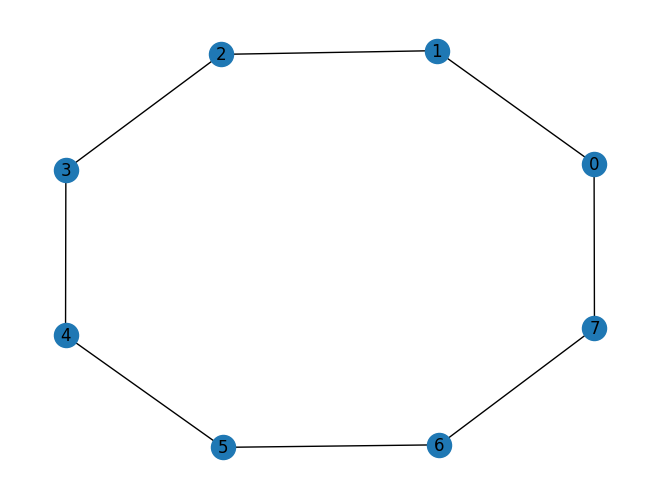

In [5]:
net = simple_network(8, "cycle")
nx.spring_layout(net)
nx.draw(net, with_labels=True)

## Simulations

In [6]:
N_SIMULATIONS = 1_000
N_STEPS = 10_000

# One entry per model: where its results are saved and how its runs stop.
MODELS = {
    "bayes": {
        "label": "Zollman (2007): bayes agents",
        "csv": "zollman_2007.csv",
        "stopping": {},  # default: all credences <= 0.5, or all > 0.99
    },
    "beta": {
        "label": "Zollman (2010): beta agents",
        "csv": "zollman_2010.csv",
        # The default tolerance stop fires within a few steps for beta agents.
        "stopping": {
            "tolerance_stopping": False,
            "choice_stability_stopping": True,
            "choice_stability_window": 1_000,
        },
    },
}

def simulation_simple(
    n_agents: int,
    shape: str,
    agent_type: str,
    n_steps: int,
    stopping: dict,
) -> dict:
    net = simple_network(n_agents, shape)
    model = VectorizedModel(
        network=net,
        n_experiments=1_000,
        uncertainty=0.001,
        agent_type=agent_type,
        **stopping,
    )
    model.run_simulation(number_of_steps=n_steps)
    result = {
        "n_agents": n_agents,
        "shape": shape,
        "conclusion": model.conclusion,
        "steps": model.n_steps,
    }
    return result

# A model whose CSV already exists is loaded, not re-run; delete the CSV to re-run it.
results = {}
for agent_type, spec in MODELS.items():
    if os.path.exists(spec["csv"]):
        results[agent_type] = pd.read_csv(spec["csv"])
        print(f"{agent_type}: loaded {spec['csv']}")
        continue
    params = [
        {
            "n_agents": n_agents,
            "shape": shape,
            "agent_type": agent_type,
            "n_steps": N_STEPS,
            "stopping": spec["stopping"],
        }
        for _ in range(N_SIMULATIONS)
        for n_agents in range(5, 11)
        for shape in ["cycle", "wheel", "complete"]
    ]
    data = list(tqdm(Parallel(return_as="generator", n_jobs=-2)(
        delayed(simulation_simple)(**params)
        for params in params
    ), total=len(params), desc=agent_type))
    df = pd.DataFrame(data, columns=["n_agents", "shape", "conclusion", "steps"])
    df.to_csv(spec["csv"], index=False)
    results[agent_type] = df

beta: 100%|██████████| 18000/18000 [40:02<00:00,  7.49it/s]  


## Plots

‘Correctness’
- `conclusion` is the share of agents on the better method when the run stops: credence > 0.99 for bayes agents, a higher Beta mean for the better method for beta agents.
- Bayes runs stop only when all agents agree, so every run ends at 0 or 1 and the plotted mean is the probability of correct learning, as in Zollman (2007). Beta runs can end with agents split, in which case a run contributes its share rather than 0 or 1.
- Bayes: qualitatively as in Zollman (2007). The complete network is worst and the cycle is best.

‘Speed’
- Bayes: our plots look very similar to Zollman’s.
- Beta `steps` include the 1,000-step stability window, so they compare across shapes but not with the bayes panel.

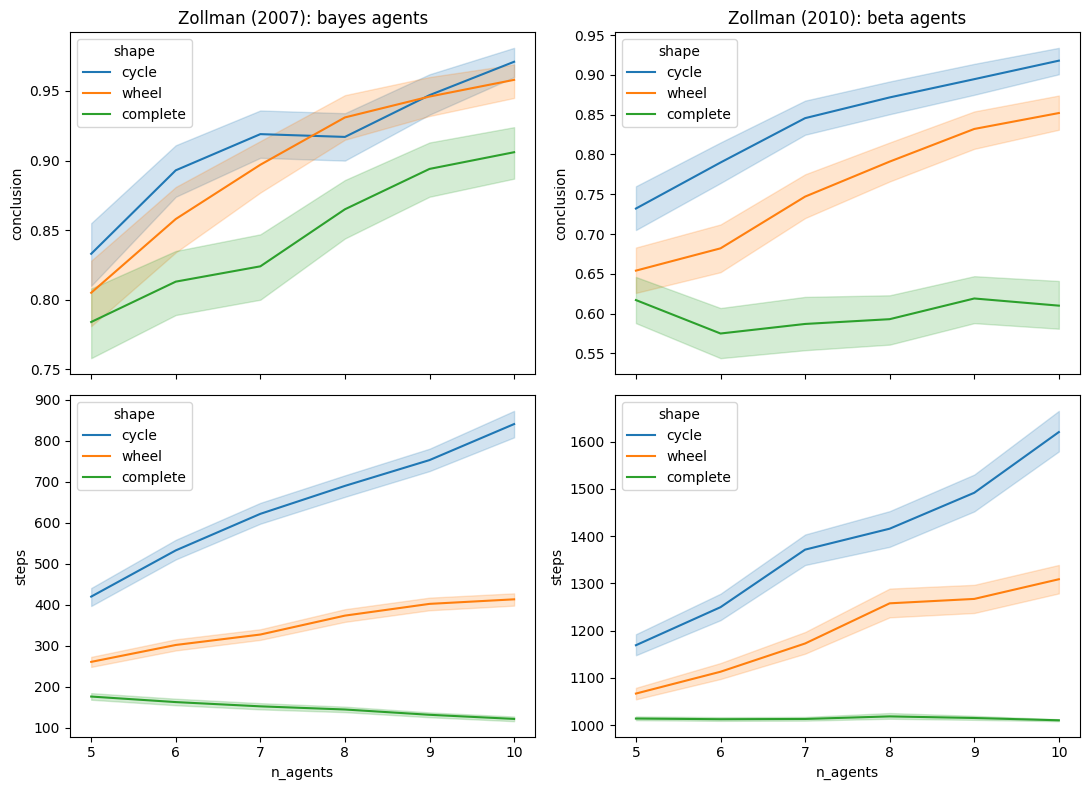

In [7]:
fig, axes = plt.subplots(2, len(results), figsize=(5.5 * len(results), 8), sharex=True, squeeze=False)
for col, (agent_type, df) in enumerate(results.items()):
    sns.lineplot(df, x="n_agents", y="conclusion", hue="shape", errorbar="ci", ax=axes[0, col])
    sns.lineplot(df, x="n_agents", y="steps", hue="shape", errorbar="ci", ax=axes[1, col])
    axes[0, col].set_title(MODELS[agent_type]["label"])
fig.tight_layout()

## Something goes wrong with the seeding! 

In [8]:
net = simple_network(10, "wheel")
model1 = VectorizedModel(network=net, n_experiments=1_000, uncertainty=0.001, agent_type="bayes")
model1.run_simulation(number_of_steps=1_000)

model2 = VectorizedModel(network=net, n_experiments=1_000, uncertainty=0.001, agent_type="bayes")
model2.run_simulation(number_of_steps=1_000)

model3 = VectorizedModel(network=net, n_experiments=1_000, uncertainty=0.001, agent_type="bayes")
model3.run_simulation(number_of_steps=1_000)

print(f"{model1.conclusion=:.3f}")
print(f"{model2.conclusion=:.3f}")
print(f"{model3.conclusion=:.3f}")
print("-"*20)
print(f"{model1.n_steps=:.0f}")
print(f"{model2.n_steps=:.0f}")
print(f"{model3.n_steps=:.0f}")

model1.conclusion=1.000
model2.conclusion=1.000
model3.conclusion=1.000
--------------------
model1.n_steps=273
model2.n_steps=386
model3.n_steps=327


In [9]:
net = simple_network(10, "wheel")
model1 = VectorizedModel(network=net, n_experiments=1_000, uncertainty=0.001, agent_type="bayes")
model1.run_simulation(number_of_steps=1_000)

model2 = VectorizedModel(network=net, n_experiments=1_000, uncertainty=0.001, agent_type="bayes")
model2.run_simulation(number_of_steps=1_000)

model3 = VectorizedModel(network=net, n_experiments=1_000, uncertainty=0.001, agent_type="bayes")
model3.run_simulation(number_of_steps=1_000)

print(f"{model1.conclusion=:.3f}")
print(f"{model2.conclusion=:.3f}")
print(f"{model3.conclusion=:.3f}")
print("-"*20)
print(f"{model1.n_steps=:.0f}")
print(f"{model2.n_steps=:.0f}")
print(f"{model3.n_steps=:.0f}")

model1.conclusion=1.000
model2.conclusion=1.000
model3.conclusion=1.000
--------------------
model1.n_steps=561
model2.n_steps=535
model3.n_steps=199
